In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

import src.phantom as phantom
import src.fft as fft
import src.kspace as ks
import src.radial_sampling as rs

<module 'src.radial_sampling' from '/content/drive/MyDrive/GoldenAngleMRI/src/radial_sampling.py'>

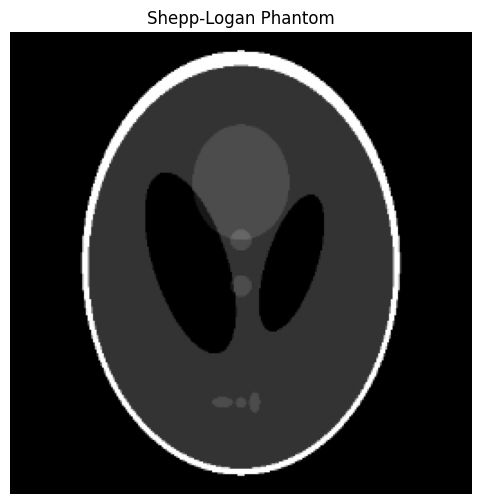

In [ ]:
# ==========================================================
# Generate the Shepp-Logan Phantom
# ==========================================================

image = phantom.generate_shepp_logan()

plt.figure(figsize=(6, 6))

plt.imshow(
    image,
    cmap="gray",
)

plt.title("Shepp-Logan Phantom")

plt.axis("off")

plt.show()

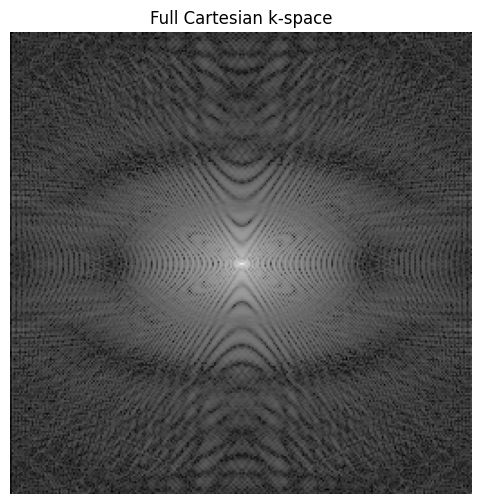

In [ ]:
# ==========================================================
# Compute Full Cartesian k-space
# ==========================================================

kspace = fft.fft2c(image)

plt.figure(figsize=(6, 6))

plt.imshow(
    ks.log_magnitude(kspace),
    cmap="gray",
)

plt.title("Full Cartesian k-space")

plt.axis("off")

plt.show()

In [ ]:
# ==========================================================
# Generate Radial Projection Angles
# ==========================================================

angles = rs.generate_radial_angles(8)

print("Angles (degrees):")

print(np.degrees(angles))

Angles (degrees):
[  0.       22.5      45.       67.5      90.      112.49999 135.
 157.49998]


In [ ]:
# ==========================================================
# Generate the Radial Trajectory
# ==========================================================

kx, ky = rs.generate_radial_trajectory(
    num_spokes=8,
    num_samples=256,
)

print("Trajectory shape:", kx.shape)

Trajectory shape: (8, 256)


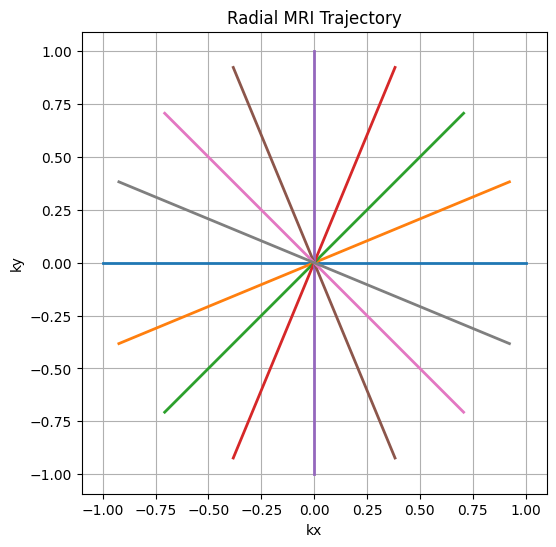

In [ ]:
# ==========================================================
# Visualize the Radial Trajectory
# ==========================================================

plt.figure(figsize=(6, 6))

for spoke in range(kx.shape[0]):

    plt.plot(
        kx[spoke],
        ky[spoke],
        linewidth=2,
    )

plt.scatter(
    0,
    0,
    color="red",
    s=50,
)

plt.title("Radial MRI Trajectory")

plt.xlabel("kx")

plt.ylabel("ky")

plt.axis("equal")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Create a Radial Sampling Mask
# ==========================================================

mask = rs.create_radial_mask(
    shape=kspace.shape,
    num_spokes=32,
)

print("Mask shape:", mask.shape)

Mask shape: (256, 256)


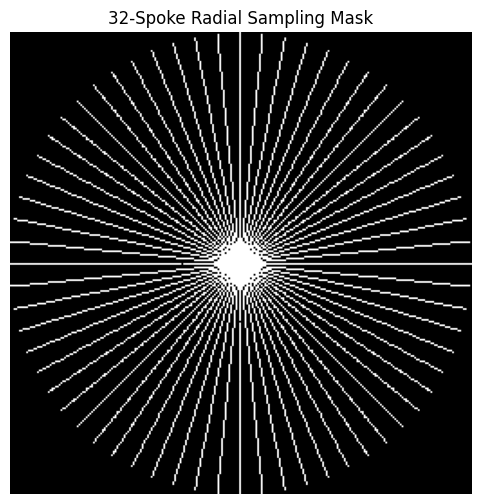

In [ ]:
# ==========================================================
# Display the Radial Sampling Mask
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(
    mask,
    cmap="gray",
    origin="lower",
)

plt.title("32-Spoke Radial Sampling Mask")

plt.axis("off")

plt.show()

In [ ]:
# ==========================================================
# Apply Radial Sampling
# ==========================================================

sampled_kspace = rs.apply_radial_sampling(
    kspace,
    mask,
)

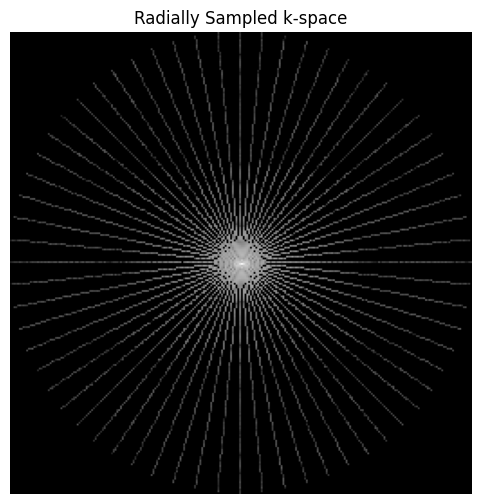

In [ ]:
# ==========================================================
# Display the Sampled k-space
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(
    ks.log_magnitude(sampled_kspace),
    cmap="gray",
)

plt.title("Radially Sampled k-space")

plt.axis("off")

plt.show()

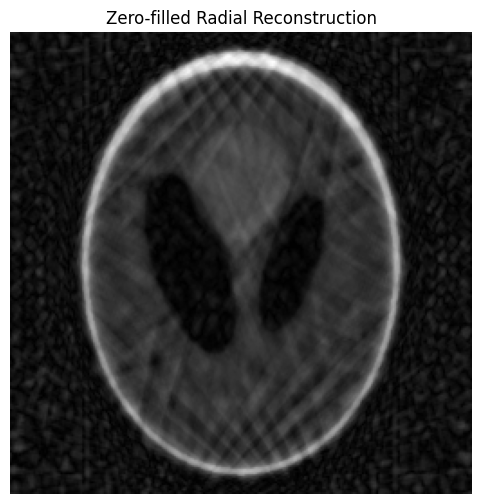

In [ ]:
# ==========================================================
# Zero-filled Reconstruction
# ==========================================================

reconstructed = rs.reconstruct_radial_image(
    sampled_kspace,
)

plt.figure(figsize=(6,6))

plt.imshow(
    reconstructed,
    cmap="gray",
)

plt.title("Zero-filled Radial Reconstruction")

plt.axis("off")

plt.show()

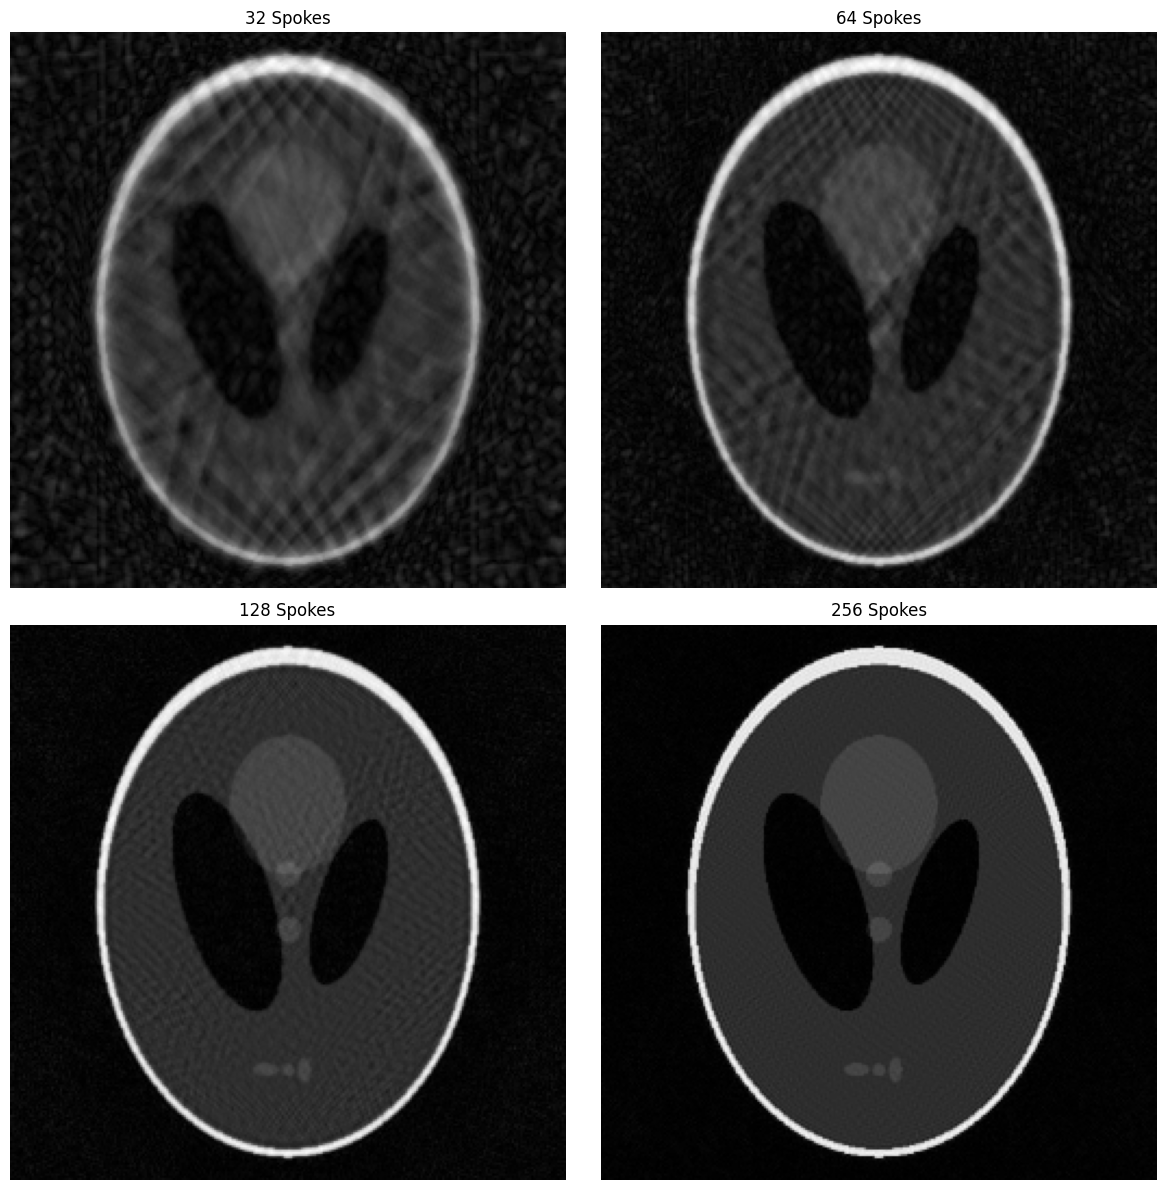

In [ ]:
# ==========================================================
# Compare Different Numbers of Spokes
# ==========================================================

spokes = [32, 64, 128, 256]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,12),
)

for ax, n in zip(axes.ravel(), spokes):

    # Create sampling mask
    mask = rs.create_radial_mask(
        shape=kspace.shape,
        num_spokes=n,
    )

    # Apply sampling
    sampled = rs.apply_radial_sampling(
        kspace,
        mask,
    )

    # Reconstruct image
    image = rs.reconstruct_radial_image(
        sampled,
    )

    ax.imshow(
        image,
        cmap="gray",
    )

    ax.set_title(f"{n} Spokes")

    ax.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# Compute Sampling Percentage
# ==========================================================

spokes = [32, 64, 128, 256]

print(f"{'Spokes':<10}{'Sampling (%)'}")

for n in spokes:

    mask = rs.create_radial_mask(
        shape=kspace.shape,
        num_spokes=n,
    )

    percentage = rs.sampling_percentage(mask)

    print(f"{n:<10}{percentage:.2f}")

Spokes    Sampling (%)
32        11.15
64        21.74
128       40.10
256       65.17


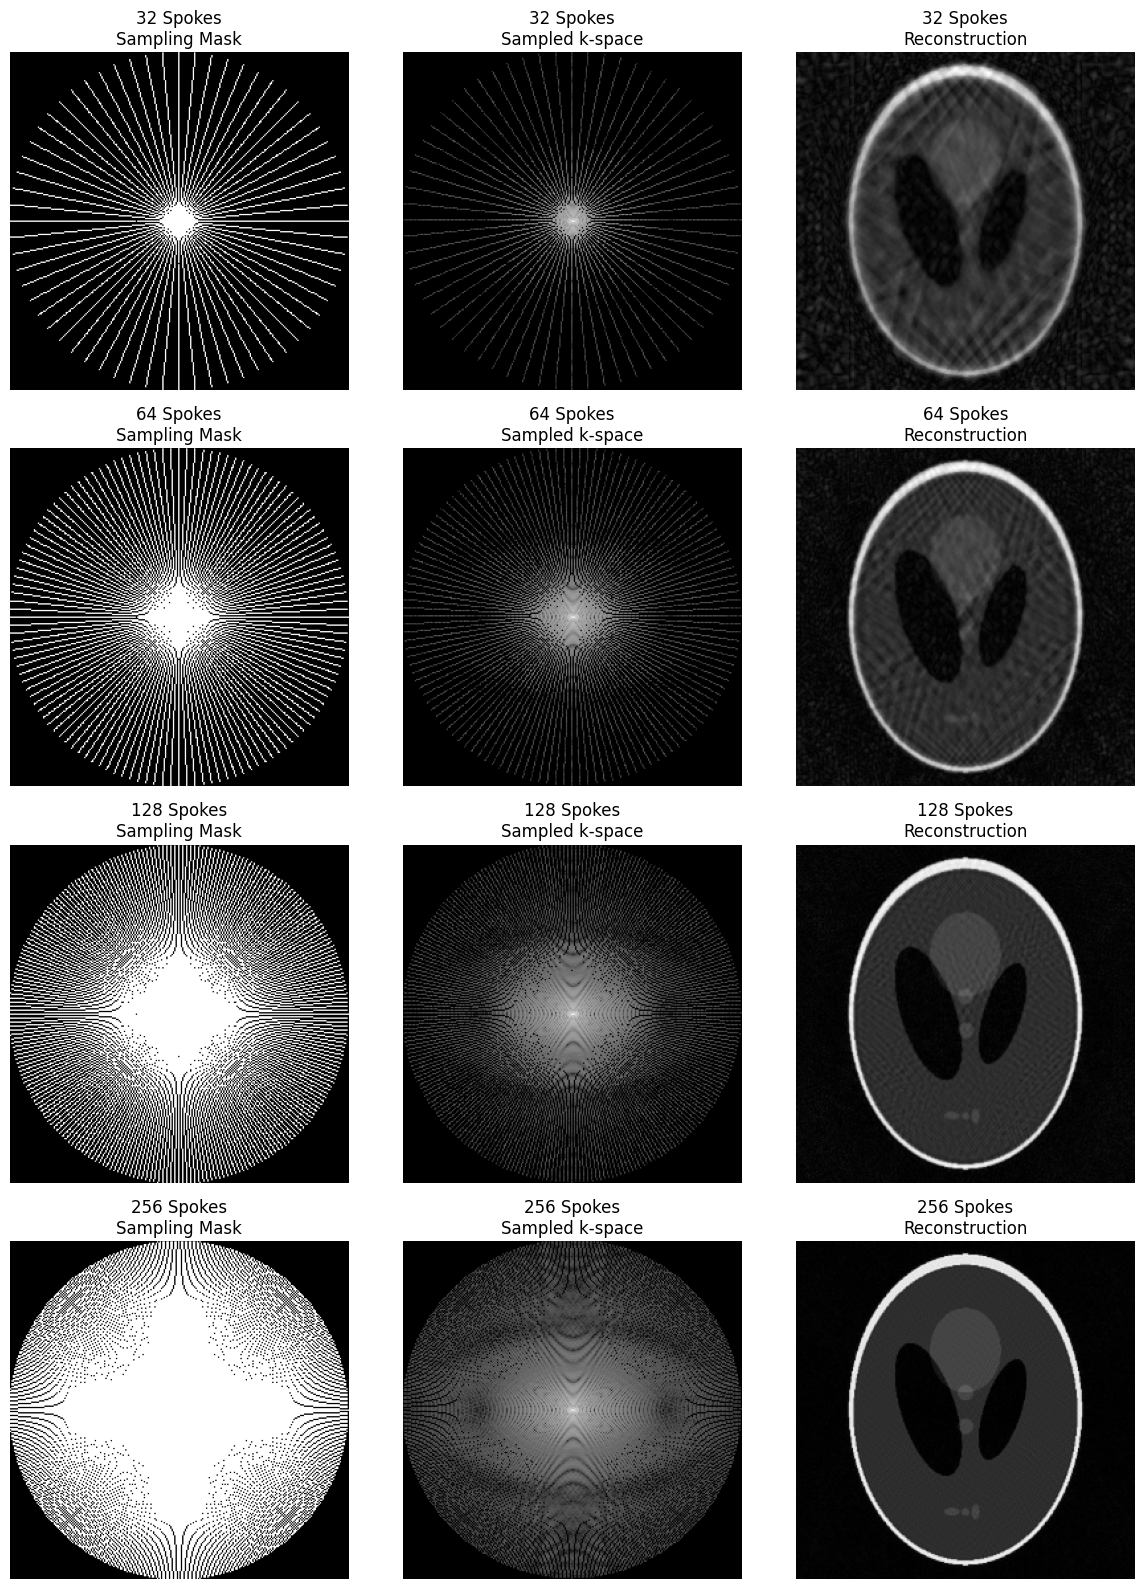

In [ ]:
# ==========================================================
# Compare Different Numbers of Radial Spokes
# ==========================================================

spokes = [32, 64, 128, 256]

# Create one row for each spoke count.
# Columns:
#   1. Sampling mask
#   2. Sampled k-space
#   3. Reconstructed image
fig, axes = plt.subplots(
    len(spokes),
    3,
    figsize=(12, 16),
)

for row, n in enumerate(spokes):

    # --------------------------------------------------
    # Create the radial sampling mask.
    # --------------------------------------------------
    mask = rs.create_radial_mask(
        shape=kspace.shape,
        num_spokes=n,
    )

    # --------------------------------------------------
    # Apply radial sampling.
    # --------------------------------------------------
    sampled_kspace = rs.apply_radial_sampling(
        kspace,
        mask,
    )

    # --------------------------------------------------
    # Reconstruct the image.
    # --------------------------------------------------
    reconstructed = rs.reconstruct_radial_image(
        sampled_kspace,
    )

    # --------------------------------------------------
    # Display the radial sampling mask.
    # --------------------------------------------------
    axes[row, 0].imshow(
        mask,
        cmap="gray",
        origin="lower",
    )

    axes[row, 0].set_title(f"{n} Spokes\nSampling Mask")

    axes[row, 0].axis("off")

    # --------------------------------------------------
    # Display the sampled k-space.
    # --------------------------------------------------
    axes[row, 1].imshow(
        ks.log_magnitude(sampled_kspace),
        cmap="gray",
    )

    axes[row, 1].set_title(f"{n} Spokes\nSampled k-space")

    axes[row, 1].axis("off")

    # --------------------------------------------------
    # Display the reconstructed image.
    # --------------------------------------------------
    axes[row, 2].imshow(
        reconstructed,
        cmap="gray",
    )

    axes[row, 2].set_title(f"{n} Spokes\nReconstruction")

    axes[row, 2].axis("off")

plt.tight_layout()

plt.show()

## Discussion

This investigation examined the effect of radial k-space sampling on MRI image reconstruction using zero-filled inverse Fourier reconstruction. Unlike Cartesian acquisition, radial sampling repeatedly traverses the center of k-space, ensuring that low spatial frequencies are acquired by every projection. Consequently, radial sampling provides greater robustness to motion and graceful degradation under undersampling.

The experiments demonstrate that increasing the number of radial spokes improves angular coverage of k-space and progressively reduces streak artifacts in the reconstructed images. With fewer spokes, incomplete angular sampling produces characteristic streak artifacts and loss of fine structural detail. As additional spokes are acquired, reconstruction quality improves and anatomical structures become more accurately represented.

These findings illustrate the trade-off between acquisition time and image quality in radial MRI. Compared with Cartesian undersampling, which typically produces coherent aliasing artifacts, radial undersampling distributes missing information across multiple projection angles, resulting in streak artifacts that are generally less structured and often less visually disruptive. This property contributes to the widespread use of radial sampling in applications such as cardiac, abdominal, and free-breathing MRI.